## 1. Importing Libraries

In [142]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

## 2. Loading the Dataset

In [143]:
df=pd.read_csv("car data.csv")
df

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


## 3. Exploratory Data Analysis

In [144]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [145]:
df.tail()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
296,city,2016,9.50,11.6,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.9,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.0,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.5,9000,Diesel,Dealer,Manual,0
300,brio,2016,5.30,5.9,5464,Petrol,Dealer,Manual,0


In [146]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [147]:
df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [148]:
df.shape

(301, 9)

In [149]:
df.columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven',
       'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner'],
      dtype='object')

In [150]:
df.index

RangeIndex(start=0, stop=301, step=1)

In [151]:
df.isna().sum()/len("car data.csv")

Car_Name         0.0
Year             0.0
Selling_Price    0.0
Present_Price    0.0
Kms_Driven       0.0
Fuel_Type        0.0
Seller_Type      0.0
Transmission     0.0
Owner            0.0
dtype: float64

## 4. Feature Engineering

-> Calculating Car Age

In [152]:
df['Car_Age'] = 2026 - df['Year']

df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,12
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,13
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,9
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,15
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,12


-> Removing unnecessary columns

In [153]:
df.drop(['Car_Name','Year'], axis=1, inplace=True)

## 5. Convert Categorical Data (Encoding)

-> Checking Categories  

In [154]:
print(df['Fuel_Type'].unique())
print(df['Seller_Type'].unique())
print(df['Transmission'].unique())

['Petrol' 'Diesel' 'CNG']
['Dealer' 'Individual']
['Manual' 'Automatic']


In [155]:
df = pd.get_dummies(
    df,
    drop_first=True
)

df.head()

,Selling_Price,Present_Price,Kms_Driven,Owner,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,3.35,5.59,27000,0,12,False,True,False,True
1,4.75,9.54,43000,0,13,True,False,False,True
2,7.25,9.85,6900,0,9,False,True,False,True
3,2.85,4.15,5200,0,15,False,True,False,True
4,4.60,6.87,42450,0,12,True,False,False,True


## 6. Separating Feature and Target Variable

X -> feature and y -> target

In [156]:
y = df['Selling_Price']
X = df.drop('Selling_Price', axis=1)

## 7. Train-Test Split

In [157]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [158]:
print(X_train.shape)
print(X_test.shape)

(240, 8)
(61, 8)


## 8. Model Building

#### Linear  Regression  Model

In [159]:
lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


#### Random  Forest  Model

In [160]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## 9. Predictions

#### Linear  Regression  Predictions -

In [161]:
lr_pred = lr_model.predict(X_test)

#### Random  Forest  Predictions -

In [162]:
rf_pred = rf_model.predict(X_test)

## 10. Model Evaluation

#### Linear regression model

In [163]:
print("Linear Regression Results")

print("MAE:", mean_absolute_error(y_test, lr_pred))

print("MSE:", mean_squared_error(y_test, lr_pred))

print("R2 Score:", r2_score(y_test, lr_pred))

Linear Regression Results
MAE: 1.2162256821297002
MSE: 3.478803970637871
R2 Score: 0.848981302489908


#### Random forest model

In [164]:
print("Random Forest Results")

print("MAE:", mean_absolute_error(y_test, rf_pred))

print("MSE:", mean_squared_error(y_test, rf_pred))

print("R2 Score:", r2_score(y_test, rf_pred))

Random Forest Results
MAE: 0.63872131147541
MSE: 0.9215642422950816
R2 Score: 0.9599938850484411


## 11. Compare Models

In [165]:
lr_r2 = r2_score(y_test, lr_pred)

rf_r2 = r2_score(y_test, rf_pred)

comparison = pd.DataFrame({
    'Model': ['Linear Regression','Random Forest'],
    'R2 Score': [lr_r2, rf_r2]
})

comparison

,Model,R2 Score
0,Linear Regression,0.848981
1,Random Forest,0.959994


## 12. Select Best Model

In [166]:
if rf_r2 > lr_r2:
    print("Random Forest is the Best Model")
else:
    print("Linear Regression is the Best Model")

Random Forest is the Best Model


## 13. Actual vs Predicted Prices (Best Model)

In [167]:
comparison_df = pd.DataFrame({
    'Actual Price': y_test,
    'Predicted Price': rf_pred
})

comparison_df.head(10)

,Actual Price,Predicted Price
177,0.35,0.4428
289,10.11,10.9870
228,4.95,4.8720
198,0.15,0.2168
60,6.95,7.8305
9,7.45,6.1810
118,1.10,1.1070
154,0.50,0.5906
164,0.45,0.4689
33,6.00,6.9020


## 14. Selling Price Distribution

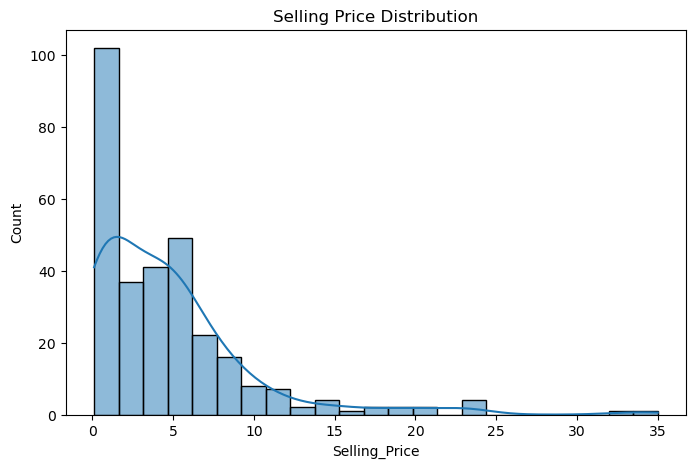

In [168]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Selling_Price'],
    kde=True
)

plt.title("Selling Price Distribution")

plt.show()

## 15. Actual vs Predicted Scatter Plot

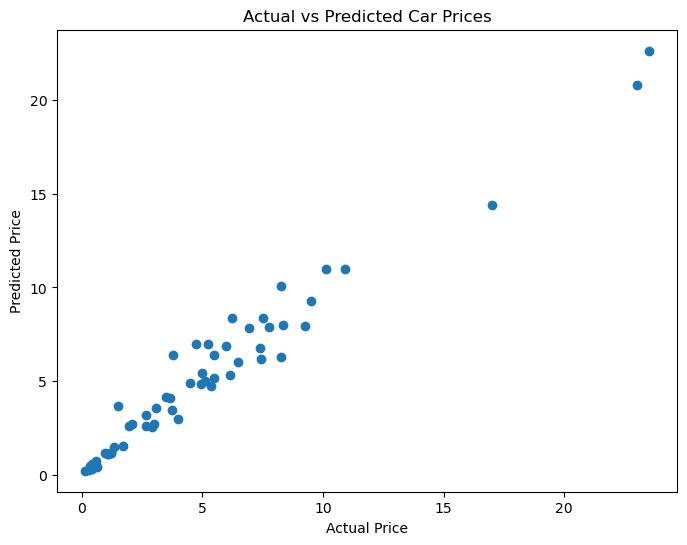

In [169]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, rf_pred)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Car Prices")

plt.show()

## 16. Feature Importance (Random Forest)

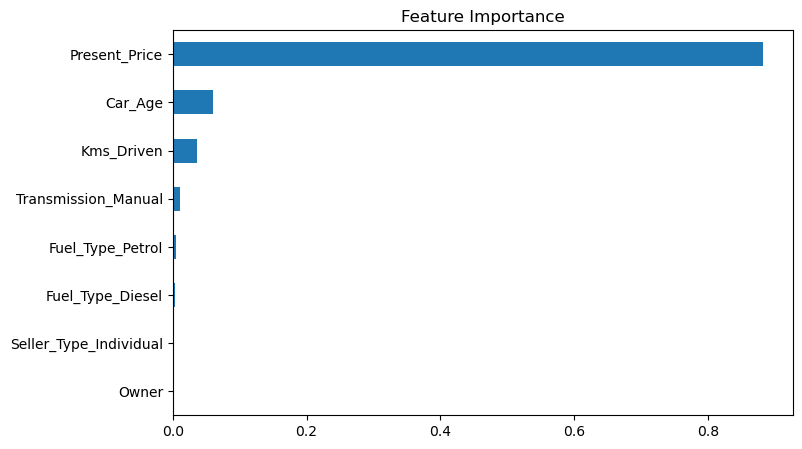

In [170]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

importance.sort_values().plot(
    kind='barh',
    figsize=(8,5)
)

plt.title("Feature Importance")

plt.show()

## 17. Predict New Car Price

In [171]:
sample_car = X_test.iloc[[0]]

predicted_price = rf.predict(sample_car)

print("Predicted Price:", predicted_price[0])

Predicted Price: 0.4427999999999999


## 18. Conclusion

This project aimed to predict used car prices using machine learning techniques.

The dataset was preprocessed through feature engineering and categorical encoding.

Two regression models were trained:
1. Linear Regression
2. Random Forest Regressor

Both models were evaluated using MAE, MSE, and R² Score.

After comparison, the model with the higher R² Score was selected as the final model.

The results show that machine learning can effectively estimate used car prices based on vehicle characteristics.